In [1]:
# Imports & Configuration
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_FILE = "SPY_1min_firstratedata.csv"

TRAIN_WINDOW = 4
SEQ_LEN      = 30
LSTM_EPOCHS  = 25
RANDOM_STATE = 42

PRUNE_IMPORTANCE_THRESHOLD = 0.0005
TOP_N_FEATURES_FALLBACK    = 12
IMPORTANCE_FOLDS           = 3

MODEL_NAMES = ["HistGBM", "RF", "Ridge", "LSTM", "Naive"]

# ── PLOT STYLE ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "axes.titlecolor":  "#e6edf3",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "axes.titlepad":    10,
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "text.color":       "#c9d1d9",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "legend.fontsize":  9,
    "lines.linewidth":  1.8,
    "patch.linewidth":  0.5,
    "font.family":      "DejaVu Sans",
})

PAL = {
    "hgb":    "#58a6ff",
    "lstm":   "#3fb950",
    "ridge":  "#d29922",
    "rf":     "#f78166",
    "naive":  "#6e7681",
    "actual": "#e6edf3",
    "error":  "#f85149",
    "accent": "#bc8cff",
    "phase":  "#238636",
}

MODEL_COLORS = {
    "HistGBM": PAL["hgb"],
    "RF":      PAL["rf"],
    "Ridge":   PAL["ridge"],
    "LSTM":    PAL["lstm"],
    "Naive":   PAL["naive"],
}

In [2]:
# Helper Functions
def calc_regression_metrics(y_true, y_pred):
    raw_true = np.expm1(y_true)
    raw_pred = np.expm1(y_pred)
    valid = raw_true > 0
    mape  = np.mean(np.abs((raw_true[valid] - raw_pred[valid]) / raw_true[valid])) * 100             if valid.sum() > 0 else np.nan
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
        "MAPE": mape,
    }


def build_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)


def shade_market_phases(ax, alpha=0.08):
    for span in [(0, 15), (375, 390)]:
        ax.axvspan(span[0], span[1], color=PAL["phase"], alpha=alpha, zorder=0)


def tick_months(ax, df_pivot):
    labels = [str(m) for m in df_pivot.index]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)


def plot_wf_lines(ax, df_pivot, ylabel, title, hline=None):
    for col in df_pivot.columns:
        ls = "--" if col == "Naive" else "-"
        ax.plot(
            range(len(df_pivot)), df_pivot[col],
            label=col, color=MODEL_COLORS.get(col, "#aaaaaa"),
            linestyle=ls, marker="o", markersize=3, linewidth=1.6,
        )
    if hline is not None:
        ax.axhline(hline, color="#6e7681", linewidth=0.8, linestyle=":")
    tick_months(ax, df_pivot)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)


def expand_event_window(dates, window=1):
    expanded = set()
    for d in dates:
        for delta in range(-window, window + 1):
            expanded.add(d + pd.Timedelta(days=delta))
    return expanded


def _make_xtick_labels(minutes_array):
    tick_pos   = np.arange(0, 390, 30)
    tick_times = [f"{(570 + m) // 60:02d}:{(570 + m) % 60:02d}" for m in tick_pos]
    return tick_pos, tick_times

In [3]:
# LSTM Regressor
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden,
            batch_first=True, num_layers=2, dropout=0.2
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [4]:
# Data Loading & Feature Engineering
def load_and_engineer_features(filepath):
    df     = pd.read_csv(filepath)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df_rth = df.set_index("timestamp").between_time("09:30", "16:00").copy()

    # Time features
    df_rth["minute_of_day"] = (df_rth.index.hour * 60 + df_rth.index.minute) - 570
    df_rth["day_of_week"]   = df_rth.index.dayofweek
    df_rth["day_of_month"]  = df_rth.index.day
    df_rth["min_sin"] = np.sin(2 * np.pi * df_rth["minute_of_day"] / 390)
    df_rth["min_cos"] = np.cos(2 * np.pi * df_rth["minute_of_day"] / 390)

    # Target
    df_rth["log_vol"] = np.log1p(df_rth["volume"])

    # Lagged volume
    df_rth["lag_1_log"] = df_rth["log_vol"].shift(1)
    df_rth["lag_5_log"] = df_rth["log_vol"].shift(5)
    df_rth["ma_10_log"] = df_rth["log_vol"].rolling(10).mean().shift(1)

    # Intraday cumulative volume
    df_rth["intraday_cum_vol"] = (
        df_rth.groupby(df_rth.index.date)["volume"]
              .transform(lambda x: x.shift(1).cumsum())
    )

    # Historical minute baseline & relative volume
    df_rth["hist_bin_avg"] = (
        df_rth.groupby("minute_of_day")["volume"]
              .transform(lambda x: x.shift(1).rolling(window=20, min_periods=5).mean())
    )
    df_rth["rvol"] = df_rth["volume"].shift(1) / (df_rth["hist_bin_avg"] + 1e-9)

    # Price features
    df_rth["ret_1"]  = df_rth["close"].pct_change().shift(1)
    df_rth["ret_5"]  = df_rth["close"].pct_change(5).shift(1)
    df_rth["ret_10"] = df_rth["close"].pct_change(10).shift(1)
    df_rth["bar_range"]  = (df_rth["high"] - df_rth["low"]).shift(1)
    df_rth["body"]       = (df_rth["close"] - df_rth["open"]).shift(1)
    df_rth["upper_wick"] = (df_rth["high"] - df_rth[["open","close"]].max(axis=1)).shift(1)
    df_rth["lower_wick"] = (df_rth[["open","close"]].min(axis=1) - df_rth["low"]).shift(1)

    # Realized volatility
    df_rth["realized_vol_5"]  = df_rth["ret_1"].rolling(5).std().shift(1)
    df_rth["realized_vol_15"] = df_rth["ret_1"].rolling(15).std().shift(1)

    # VWAP deviation
    df_rth["date_only"]   = df_rth.index.normalize()
    df_rth["pv"]          = df_rth["close"] * df_rth["volume"]
    df_rth["cum_vol_raw"] = df_rth.groupby("date_only")["volume"].cumsum()
    df_rth["cum_pv_raw"]  = df_rth.groupby("date_only")["pv"].cumsum()
    df_rth["vwap"]        = df_rth["cum_pv_raw"] / (df_rth["cum_vol_raw"] + 1e-9)
    df_rth["vwap_dev"]    = ((df_rth["close"] - df_rth["vwap"]) / (df_rth["vwap"] + 1e-9)).shift(1)

    # Market phase flag
    df_rth["market_phase"] = (df_rth["minute_of_day"].apply(lambda x: 1 if (x <= 15 or x >= 375) else 0))

    # VIX proxy (20-day realised vol of daily returns)
    daily_ret    = df_rth.groupby(df_rth.index.date)["close"].last().pct_change()
    realized_vol = daily_ret.rolling(20, min_periods=5).std() * np.sqrt(252) * 100
    df_rth["vix_proxy"] = df_rth.index.normalize().map(realized_vol.shift(1))

    # Gap % — today's open vs yesterday's close
    daily_open  = df_rth.groupby(df_rth.index.date)["open"].first()
    daily_close = df_rth.groupby(df_rth.index.date)["close"].last()
    gap_pct     = (daily_open - daily_close.shift(1)) / (daily_close.shift(1) + 1e-9) * 100
    df_rth["gap_pct"] = df_rth.index.normalize().map(gap_pct)

    # Vol regime
    df_rth["vol_regime"] = (
        df_rth["realized_vol_15"] >
        df_rth["realized_vol_15"].rolling(100, min_periods=20).mean()
    ).astype(float)

    # Macro event flags
    fomc_dates = pd.to_datetime([
        "2022-01-26","2022-03-16","2022-05-04","2022-06-15","2022-07-27",
        "2022-09-21","2022-11-02","2022-12-14","2023-02-01","2023-03-22",
        "2023-05-03","2023-06-14","2023-07-26","2023-09-20","2023-11-01","2023-12-13"
    ])
    cpi_dates = pd.to_datetime([
        "2022-01-12","2022-02-10","2022-03-10","2022-04-12","2022-05-11",
        "2022-06-10","2022-07-13","2022-08-10","2022-09-13","2022-10-13",
        "2022-11-10","2022-12-13","2023-01-12","2023-02-14","2023-03-14",
        "2023-04-12","2023-05-10","2023-06-13","2023-07-12","2023-08-10",
        "2023-09-13","2023-10-12","2023-11-14","2023-12-12"
    ])
    nfp_dates = pd.to_datetime([
        "2022-01-07","2022-02-04","2022-03-04","2022-04-01","2022-05-06",
        "2022-06-03","2022-07-08","2022-08-05","2022-09-02","2022-10-07",
        "2022-11-04","2022-12-02","2023-01-06","2023-02-03","2023-03-10",
        "2023-04-07","2023-05-05","2023-06-02","2023-07-07","2023-08-04",
        "2023-09-01","2023-10-06","2023-11-03","2023-12-08"
    ])
    opex_dates = pd.to_datetime([
        "2022-01-21","2022-02-18","2022-03-18","2022-04-14","2022-05-20",
        "2022-06-17","2022-07-15","2022-08-19","2022-09-16","2022-10-21",
        "2022-11-18","2022-12-16","2023-01-20","2023-02-17","2023-03-17",
        "2023-04-21","2023-05-19","2023-06-16","2023-07-21","2023-08-18",
        "2023-09-15","2023-10-20","2023-11-17","2023-12-15"
    ])

    fomc_window = expand_event_window(fomc_dates)
    cpi_window  = expand_event_window(cpi_dates)
    nfp_window  = expand_event_window(nfp_dates)
    # OpEx: exact date only (no ±1 window)

    df_rth["is_fomc_dates"] = df_rth["date_only"].isin(fomc_window).astype(int)
    df_rth["is_cpi_dates"]  = df_rth["date_only"].isin(cpi_window).astype(int)
    df_rth["is_nfp_dates"]  = df_rth["date_only"].isin(nfp_window).astype(int)
    df_rth["is_opex"]       = df_rth["date_only"].isin(opex_dates).astype(int)

    # Naive baseline
    df_rth["naive_pred"] = (
        df_rth.groupby("minute_of_day")["log_vol"]
              .transform(lambda x: x.shift(1).rolling(window=20, min_periods=5).mean())
    )

    features = [
        "minute_of_day", "day_of_week", "day_of_month",
        "min_sin", "min_cos",
        "lag_1_log", "lag_5_log", "ma_10_log", "intraday_cum_vol",
        "rvol", "ret_1", "ret_5", "ret_10",
        "bar_range", "body", "upper_wick", "lower_wick",
        "realized_vol_5", "realized_vol_15", "vwap_dev",
        "market_phase", "vix_proxy", "gap_pct", "vol_regime",
        "is_fomc_dates", "is_cpi_dates", "is_nfp_dates", "is_opex",
    ]

    df_model = df_rth.dropna(subset=features + ["log_vol", "naive_pred"]).copy()
    return df_model, features

In [5]:
# Walk-Forard
def get_model_predictions(model_name, X_tr, y_tr, X_te, y_te, feature_count):
    if model_name == "HistGBM":
        model = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=6,
            min_samples_leaf=20, random_state=RANDOM_STATE
        )
        model.fit(X_tr, y_tr)
        return model.predict(X_te), y_te, model

    if model_name == "RF":
        model = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=20,
            max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE
        )
        model.fit(X_tr, y_tr)
        return model.predict(X_te), y_te, model

    if model_name == "Ridge":
        pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
        pipe.fit(X_tr, y_tr)
        return pipe.predict(X_te), y_te, pipe

    if model_name == "LSTM":
        scaler    = StandardScaler().fit(X_tr)
        X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)
        X_tr_seq, y_tr_seq = build_sequences(X_tr_s, y_tr, SEQ_LEN)
        X_te_seq, y_te_seq = build_sequences(X_te_s, y_te, SEQ_LEN)
        if len(X_tr_seq) < 50 or len(X_te_seq) < 1:
            return np.full(len(y_te), np.nan), y_te, None
        tr_ds     = TensorDataset(
            torch.tensor(X_tr_seq, dtype=torch.float32),
            torch.tensor(y_tr_seq, dtype=torch.float32).view(-1, 1)
        )
        tr_loader = DataLoader(tr_ds, batch_size=256, shuffle=True)
        lstm      = LSTMRegressor(feature_count)
        opt       = torch.optim.Adam(lstm.parameters(), lr=5e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=LSTM_EPOCHS)
        criterion = nn.MSELoss()
        for _ in range(LSTM_EPOCHS):
            lstm.train()
            for xb, yb in tr_loader:
                opt.zero_grad()
                loss = criterion(lstm(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(lstm.parameters(), 1.0)
                opt.step()
            scheduler.step()
        lstm.eval()
        with torch.no_grad():
            pred_seq = lstm(torch.tensor(X_te_seq, dtype=torch.float32)).numpy().flatten()
        pred = np.full(len(y_te), np.nan)
        pred[SEQ_LEN:] = pred_seq
        return pred, y_te, None

    raise ValueError(f"Unknown model: {model_name}")


def run_walk_forward(df_model, features, model_names):
    X        = df_model[features]
    y        = df_model["log_vol"]
    df_local = df_model.copy()
    df_local["ym"] = df_local.index.to_period("M")
    all_months     = sorted(df_local["ym"].unique())
    wf_results     = []
    print(f"Starting walk-forward  |  TRAIN_WINDOW={TRAIN_WINDOW}\n")
    for i in range(TRAIN_WINDOW, len(all_months)):
        test_month   = all_months[i]
        train_months = all_months[i - TRAIN_WINDOW:i]
        mask_train   = df_local["ym"].isin(train_months)
        mask_test    = df_local["ym"] == test_month
        X_tr, y_tr   = X.loc[mask_train].values, y.loc[mask_train].values
        X_te, y_te   = X.loc[mask_test].values,  y.loc[mask_test].values
        if len(X_te) == 0:
            continue
        print(f"  {test_month} | train: {len(X_tr):,}  test: {len(X_te):,}")
        for model_name in model_names:
            if model_name == "Naive":
                pred   = df_local.loc[mask_test, "naive_pred"].values
                y_eval = y_te
            else:
                pred, y_eval, _ = get_model_predictions(
                    model_name, X_tr, y_tr, X_te, y_te, len(features)
                )
            valid = ~np.isnan(pred) & ~np.isnan(y_eval)
            if valid.sum() < 5:
                continue
            metrics = calc_regression_metrics(y_eval[valid], pred[valid])
            wf_results.append({"Month": str(test_month), "Model": model_name, **metrics})
    return pd.DataFrame(wf_results)


def summarize_results(results_df):
    summary = results_df.groupby("Model")[["MAE","RMSE","R2","MAPE"]].agg(["mean","std"])
    summary.columns = ["_".join(c) for c in summary.columns]
    return summary


def get_best_model(summary_df):
    return summary_df.sort_values(["MAE_mean","R2_mean"], ascending=[True,False]).index[0]

In [6]:
# Walk-Forward Importance, Pruning & Model Fit
def compute_importance_walk_forward(best_model_name, df_model, features, n_folds=IMPORTANCE_FOLDS):
    if best_model_name not in ["HistGBM", "RF", "Ridge"]:
        raise ValueError(f"Importance not supported for {best_model_name}")
    X        = df_model[features]
    y        = df_model["log_vol"]
    df_local = df_model.copy()
    df_local["ym"] = df_local.index.to_period("M")
    all_months     = sorted(df_local["ym"].unique())
    fold_indices   = range(max(TRAIN_WINDOW, len(all_months) - n_folds), len(all_months))
    fold_imps      = []
    print(f"Computing walk-forward importance over {len(list(fold_indices))} folds...")
    for i in fold_indices:
        test_month   = all_months[i]
        train_months = all_months[i - TRAIN_WINDOW:i]
        mask_train   = df_local["ym"].isin(train_months)
        mask_test    = df_local["ym"] == test_month
        X_tr, y_tr   = X.loc[mask_train].values, y.loc[mask_train].values
        X_te, y_te   = X.loc[mask_test].values,  y.loc[mask_test].values
        if len(X_te) < 10:
            continue
        print(f"  {test_month} | train: {len(X_tr):,}  test: {len(X_te):,}")
        _, _, fitted = get_model_predictions(best_model_name, X_tr, y_tr, X_te, y_te, len(features))
        res = permutation_importance(
            fitted, X_te, y_te, n_repeats=10,
            random_state=RANDOM_STATE, n_jobs=-1,
            scoring="neg_mean_absolute_error"
        )
        fold_imps.append(res.importances_mean)
    if not fold_imps:
        raise ValueError("No importance folds computed.")
    imp_df = pd.DataFrame({
        "Feature":    features,
        "Importance": np.mean(fold_imps, axis=0),
        "Std":        np.std(fold_imps,  axis=0),
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    return imp_df


def prune_features(imp_df):
    kept = imp_df.loc[imp_df["Importance"] > PRUNE_IMPORTANCE_THRESHOLD, "Feature"].tolist()
    return kept if kept else imp_df.head(TOP_N_FEATURES_FALLBACK)["Feature"].tolist()


def fit_best_model(best_model_name, X_tr, y_tr):
    if best_model_name == "HistGBM":
        m = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=6,
            min_samples_leaf=20, random_state=RANDOM_STATE
        )
    elif best_model_name == "RF":
        m = RandomForestRegressor(
            n_estimators=300, max_depth=12, min_samples_leaf=20,
            max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE
        )
    elif best_model_name == "Ridge":
        m = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    else:
        raise ValueError(f"fit_best_model not implemented for: {best_model_name}")
    m.fit(X_tr, y_tr)
    return m

In [7]:
# Quantile Models (Median / Q05 / Q95)
def fit_quantile_models(X_tr, y_tr):
    base = dict(max_iter=300, learning_rate=0.05, max_depth=6,
                min_samples_leaf=20, random_state=RANDOM_STATE)
    models = {
        "median": HistGradientBoostingRegressor(loss="squared_error",      **base),
        "q05":    HistGradientBoostingRegressor(loss="quantile", quantile=0.05, **base),
        "q95":    HistGradientBoostingRegressor(loss="quantile", quantile=0.95, **base),
    }
    for name, m in models.items():
        print(f"  Fitting: {name} ...")
        m.fit(X_tr, y_tr)
    return models


def evaluate_quantile_models(q_models, X_te, y_te):
    pred_median = q_models["median"].predict(X_te)
    pred_q05    = np.minimum(q_models["q05"].predict(X_te), pred_median)
    pred_q95    = np.maximum(q_models["q95"].predict(X_te), pred_median)

    in_interval    = (y_te >= pred_q05) & (y_te <= pred_q95)
    interval_width = pred_q95 - pred_q05

    def quantile(y, q_pred, alpha):
        err = y - q_pred
        return np.mean(np.where(err >= 0, alpha * err, (alpha - 1) * err))

    diag = pd.Series({
        "Coverage_90pct_interval":   in_interval.mean(),
        "Mean_interval_width_log":   interval_width.mean(),
        "Median_interval_width_log": np.median(interval_width),
        "Quantile_Q05":               quantile(y_te, pred_q05, 0.05),
        "Quantile_Q95":               quantile(y_te, pred_q95, 0.95),
        "Median_MAE":                mean_absolute_error(y_te, pred_median),
        "Median_R2":                 r2_score(y_te, pred_median),
    })
    results = pd.DataFrame({
        "actual": y_te, "pred_median": pred_median,
        "pred_q05": pred_q05, "pred_q95": pred_q95,
    })
    return results, diag

In [8]:
# Plot Functions
def plot_model_comparison(results_df):
    wf_mae  = results_df.pivot(index="Month", columns="Model", values="MAE").dropna(how="all")
    wf_rmse = results_df.pivot(index="Month", columns="Model", values="RMSE").dropna(how="all")
    wf_r2   = results_df.pivot(index="Month", columns="Model", values="R2").dropna(how="all")
    wf_mape = results_df.pivot(index="Month", columns="Model", values="MAPE").dropna(how="all")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Walk-Forward Model Comparison", fontsize=15, color="#e6edf3", y=1.01)
    plot_wf_lines(axes[0,0], wf_mae,  "MAE",      "Walk-forward MAE by month")
    plot_wf_lines(axes[0,1], wf_rmse, "RMSE",     "Walk-forward RMSE by month")
    plot_wf_lines(axes[1,0], wf_r2,   "R²",       "Walk-forward R² by month", hline=0.0)
    plot_wf_lines(axes[1,1], wf_mape, "MAPE (%)", "Walk-forward MAPE by month")
    plt.tight_layout(rect=[0,0,1,1])
    plt.show()


def plot_feature_importance(imp_df, best_model_name):
    plot_df = imp_df.sort_values("Importance", ascending=True)
    colors  = [PAL["accent"] if v > PRUNE_IMPORTANCE_THRESHOLD else PAL["naive"]
               for v in plot_df["Importance"]]
    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["Feature"], plot_df["Importance"], color=colors,
             xerr=plot_df["Std"], error_kw={"elinewidth": 0.8, "ecolor": "#8b949e"})
    plt.axvline(PRUNE_IMPORTANCE_THRESHOLD, color=PAL["error"], linewidth=1,
                linestyle="--", label=f"Prune threshold ({PRUNE_IMPORTANCE_THRESHOLD})")
    plt.title(f"Walk-Forward Permutation Importance — {best_model_name}\n"
              f"(averaged over last {IMPORTANCE_FOLDS} folds, error bars = fold std)")
    plt.xlabel("Mean importance (neg MAE drop)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_best_model_diagnostics(df_model, split, best_model_name, best_model_fit, features):
    X_te_full = df_model.iloc[split:][features]
    y_te_full = df_model.iloc[split:]["log_vol"].values
    pred      = best_model_fit.predict(X_te_full)
    df_plot   = df_model.iloc[split:].copy()
    df_plot["pred_log"] = pred

    # 1. U-shape
    u_actual = df_plot.groupby("minute_of_day")["log_vol"].mean()
    u_pred   = df_plot.groupby("minute_of_day")["pred_log"].mean()
    plt.figure(figsize=(10, 5))
    shade_market_phases(plt.gca())
    plt.plot(u_actual.index, u_actual.values, label="Actual",    color=PAL["actual"], linewidth=2)
    plt.plot(u_pred.index,   u_pred.values,   label="Predicted", color=PAL["hgb"],    linestyle="--")
    plt.title(f"Intraday U-Shape — {best_model_name}")
    plt.xlabel("Minute of day (0 = 09:30)")
    plt.ylabel("Mean log-volume")
    plt.legend(); plt.tight_layout(); plt.show()

    # 2. 5-minute pattern
    df_plot["minute_mod_5"] = df_plot["minute_of_day"] % 5
    pa = df_plot.groupby("minute_mod_5")["log_vol"].mean()
    pp = df_plot.groupby("minute_mod_5")["pred_log"].mean()
    plt.figure(figsize=(8, 5))
    plt.plot(pa.index, pa.values, marker="o", label="Actual",    color=PAL["actual"])
    plt.plot(pp.index, pp.values, marker="o", linestyle="--", label="Predicted", color=PAL["hgb"])
    plt.title(f"5-Minute Tick Pattern — {best_model_name}")
    plt.xlabel("Minute mod 5"); plt.ylabel("Mean log-volume")
    plt.legend(); plt.tight_layout(); plt.show()

    # 3. Actual vs predicted scatter
    plt.figure(figsize=(7, 7))
    plt.scatter(y_te_full, pred, alpha=0.08, s=5, color=PAL["hgb"])
    lims = [min(y_te_full.min(), pred.min()), max(y_te_full.max(), pred.max())]
    plt.plot(lims, lims, linestyle="--", color=PAL["error"])
    plt.title(f"Actual vs Predicted — {best_model_name}")
    plt.xlabel("Actual log-volume"); plt.ylabel("Predicted log-volume")
    plt.tight_layout(); plt.show()

    # 4. Residual distribution
    residuals = y_te_full - pred
    plt.figure(figsize=(10, 5))
    plt.hist(residuals, bins=80, alpha=0.7, color=PAL["accent"], density=True)
    plt.axvline(0, linestyle="--", color=PAL["actual"])
    plt.title(f"Residual Distribution — {best_model_name}")
    plt.xlabel("Residual (actual - predicted)")
    plt.tight_layout(); plt.show()


def plot_quantile_intervals(q_models, df_te, features, best_model_name, sample_date=None):
    df_te = df_te.copy()
    df_te["pred_median"] = q_models["median"].predict(df_te[features])
    df_te["pred_q05"]    = np.minimum(q_models["q05"].predict(df_te[features]), df_te["pred_median"])
    df_te["pred_q95"]    = np.maximum(q_models["q95"].predict(df_te[features]), df_te["pred_median"])
    df_te["interval_width"] = df_te["pred_q95"] - df_te["pred_q05"]
    df_te["in_interval"] = (
        (df_te["log_vol"] >= df_te["pred_q05"]) &
        (df_te["log_vol"] <= df_te["pred_q95"])
    )
    test_dates = sorted(df_te.index.normalize().unique())
    if sample_date is None:
        daily_vol   = df_te.groupby(df_te.index.normalize())["volume"].sum()
        lo, hi      = daily_vol.quantile(0.45), daily_vol.quantile(0.55)
        candidates  = daily_vol[daily_vol.between(lo, hi)]
        sample_date = candidates.index[0] if len(candidates) else test_dates[len(test_dates)//2]

    df_day = df_te[df_te.index.normalize() == sample_date].sort_values("minute_of_day")
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1.4]})
    fig.suptitle(
        f"Quantile Interval — {best_model_name}  |  Q05 / Median / Q95\n"
        f"Sample day: {pd.Timestamp(sample_date).date()}",
        fontsize=14, color="#e6edf3"
    )
    ax  = axes[0]
    shade_market_phases(ax)
    mins = df_day["minute_of_day"].values
    ax.fill_between(mins, df_day["pred_q05"].values, df_day["pred_q95"].values,
                    color=PAL["hgb"], alpha=0.20, label="Q05–Q95 interval")
    ax.plot(mins, df_day["log_vol"].values,     color=PAL["actual"], linewidth=1.8, label="Actual", zorder=4)
    ax.plot(mins, df_day["pred_median"].values, color=PAL["hgb"],    linewidth=1.4, linestyle="--", label="Median", zorder=3)
    ax.plot(mins, df_day["pred_q05"].values,    color=PAL["ridge"],  linewidth=0.9, linestyle=":", label="Q05", zorder=3)
    ax.plot(mins, df_day["pred_q95"].values,    color=PAL["rf"],     linewidth=0.9, linestyle=":", label="Q95", zorder=3)
    day_cov  = df_day["in_interval"].mean() * 100
    full_cov = df_te["in_interval"].mean() * 100
    ax.text(0.02, 0.96,
            f"This day coverage: {day_cov:.1f}%  |  Full test-set coverage: {full_cov:.1f}%  (target 90%)",
            transform=ax.transAxes, color="#8b949e", fontsize=9, va="top")
    ax.set_ylabel("Log-volume"); ax.set_xticklabels([]); ax.legend(loc="upper right", fontsize=8)

    ax2 = axes[1]
    shade_market_phases(ax2)
    width_by_min = df_te.groupby("minute_of_day")["interval_width"].mean()
    ax2.fill_between(width_by_min.index, 0, width_by_min.values, color=PAL["accent"], alpha=0.5)
    ax2.plot(width_by_min.index, width_by_min.values, color=PAL["accent"], linewidth=1.4)
    ax2.set_ylabel("Mean interval width\n(log-vol)"); ax2.set_xlabel("Minute of day (0 = 09:30)")
    tick_pos, tick_times = _make_xtick_labels(None)
    ax2.set_xticks(tick_pos); ax2.set_xticklabels(tick_times, fontsize=8)
    plt.tight_layout(); plt.show()


def plot_error_heatmap(df_model, split, best_model_name, best_model_fit, features):
    df_te = df_model.iloc[split:].copy()
    df_te["pred_log"]  = best_model_fit.predict(df_te[features])
    df_te["abs_error"] = (df_te["log_vol"] - df_te["pred_log"]).abs()
    pivot = (
        df_te.groupby(["day_of_week","minute_of_day"])["abs_error"]
             .mean().unstack(level="minute_of_day")
    )
    pivot = pivot.reindex(index=range(5))
    pivot.index = ["Mon","Tue","Wed","Thu","Fri"]
    fig, ax = plt.subplots(figsize=(18, 4))
    sns.heatmap(pivot, ax=ax, cmap="magma", linewidths=0,
                xticklabels=False, yticklabels=True,
                cbar_kws={"label":"Mean abs error (log-vol)","shrink":0.8})
    all_minutes = pivot.columns.tolist()
    tick_pos    = [all_minutes.index(m) for m in range(0, 390, 30) if m in all_minutes]
    tick_labels = [f"{(570+m)//60:02d}:{(570+m)%60:02d}" for m in range(0, 390, 30) if m in all_minutes]
    ax.set_xticks([p + 0.5 for p in tick_pos])
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    for bmin, blabel in [(15,"open buffer"),(375,"close buffer")]:
        if bmin in all_minutes:
            xpos = all_minutes.index(bmin) + 0.5
            ax.axvline(xpos, color="#58a6ff", linewidth=1.0, linestyle="--", alpha=0.7)
            ax.text(xpos + 1, -0.3, blabel, color="#58a6ff", fontsize=7, va="top")
    ax.set_title(
        f"Error Heatmap — {best_model_name}  |  Day-of-week × Minute-of-day\n"
        "(brighter = higher mean absolute error in log-volume)", fontsize=13
    )
    ax.set_xlabel("Time of day"); ax.set_ylabel(""); ax.tick_params(axis="y", rotation=0)
    plt.tight_layout(); plt.show()

In [9]:
# Trading Strategy Plot Function 
def plot_strategy_results(trades_df, df_oos):
    running_max = df_oos["strategy_equity"].cummax()
    drawdown    = df_oos["strategy_equity"] / running_max - 1

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Volume-Based Trading Strategy", fontsize=15, color="#e6edf3")

    # 1. Equity curve
    ax = axes[0, 0]
    ax.plot(df_oos.index, df_oos["strategy_equity"],  label="Strategy",   color=PAL["hgb"])
    ax.plot(df_oos.index, df_oos["benchmark_equity"], label="Buy & Hold", color=PAL["naive"], linestyle="--")
    ax.set_title("Equity curve"); ax.set_ylabel("Growth of $1"); ax.legend()

    # 2. Trade return distribution
    ax = axes[0, 1]
    ax.hist(trades_df["net_return"], bins=40, alpha=0.75, color=PAL["accent"])
    ax.axvline(0, color=PAL["actual"], linestyle="--", linewidth=1)
    ax.set_title("Trade return distribution"); ax.set_xlabel("Net return per trade")

    # 3. Drawdown
    ax = axes[1, 0]
    ax.fill_between(df_oos.index, drawdown, 0, color=PAL["error"], alpha=0.6)
    ax.set_title("Drawdown"); ax.set_ylabel("Drawdown")

    # 4. Net return by interval-width bucket (confidence)
    ax = axes[1, 1]
    trades_df["width_bucket"] = pd.cut(
        trades_df["interval_width"],
        bins=[0, 0.1, 0.2, 0.3, np.inf],
        labels=["<0.1", "0.1-0.2", "0.2-0.3", ">0.3"]
    )
    trades_df.groupby("width_bucket", observed=True)["net_return"].mean().plot(
        kind="bar", ax=ax, color=PAL["lstm"]
    )
    ax.axhline(0, color="#6e7681", linewidth=0.8)
    ax.set_title("Avg return by model confidence\n(narrower interval = more confident)")
    ax.set_ylabel("Mean net return"); ax.tick_params(axis="x", rotation=30)

    plt.tight_layout(); plt.show()

In [10]:
# Load data
df_model, all_features = load_and_engineer_features(DATA_FILE)
print(f"Rows after preprocessing: {len(df_model):,}")
print(f"Feature count: {len(all_features)}")

Rows after preprocessing: 95,403
Feature count: 28


## Cell 11 — Walk-Forward Model Comparison

Starting walk-forward  |  TRAIN_WINDOW=4

  2023-02 | train: 30,359  test: 7,410
  2023-03 | train: 31,529  test: 8,970
  2023-04 | train: 32,370  test: 7,410
  2023-05 | train: 31,590  test: 8,580
  2023-06 | train: 32,370  test: 8,186
  2023-07 | train: 33,146  test: 7,718
  2023-08 | train: 31,894  test: 8,970
  2023-09 | train: 33,454  test: 7,800
         MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std  MAPE_mean  \
Model                                                                         
HistGBM    0.3174   0.0164     0.4235    0.0696   0.6172  0.0574    52.1127   
LSTM       0.3526   0.0199     0.4632    0.0639   0.5417  0.0472    51.0440   
Naive      0.4286   0.0298     0.5616    0.0790   0.3263  0.0747   142.8611   
RF         0.3282   0.0183     0.4367    0.0710   0.5932  0.0579    55.8731   
Ridge      0.3340   0.0111     0.4288    0.0188   0.6011  0.0486    35.4327   

         MAPE_std  
Model              
HistGBM   55.6687  
LSTM      42.9595  
Naive    279

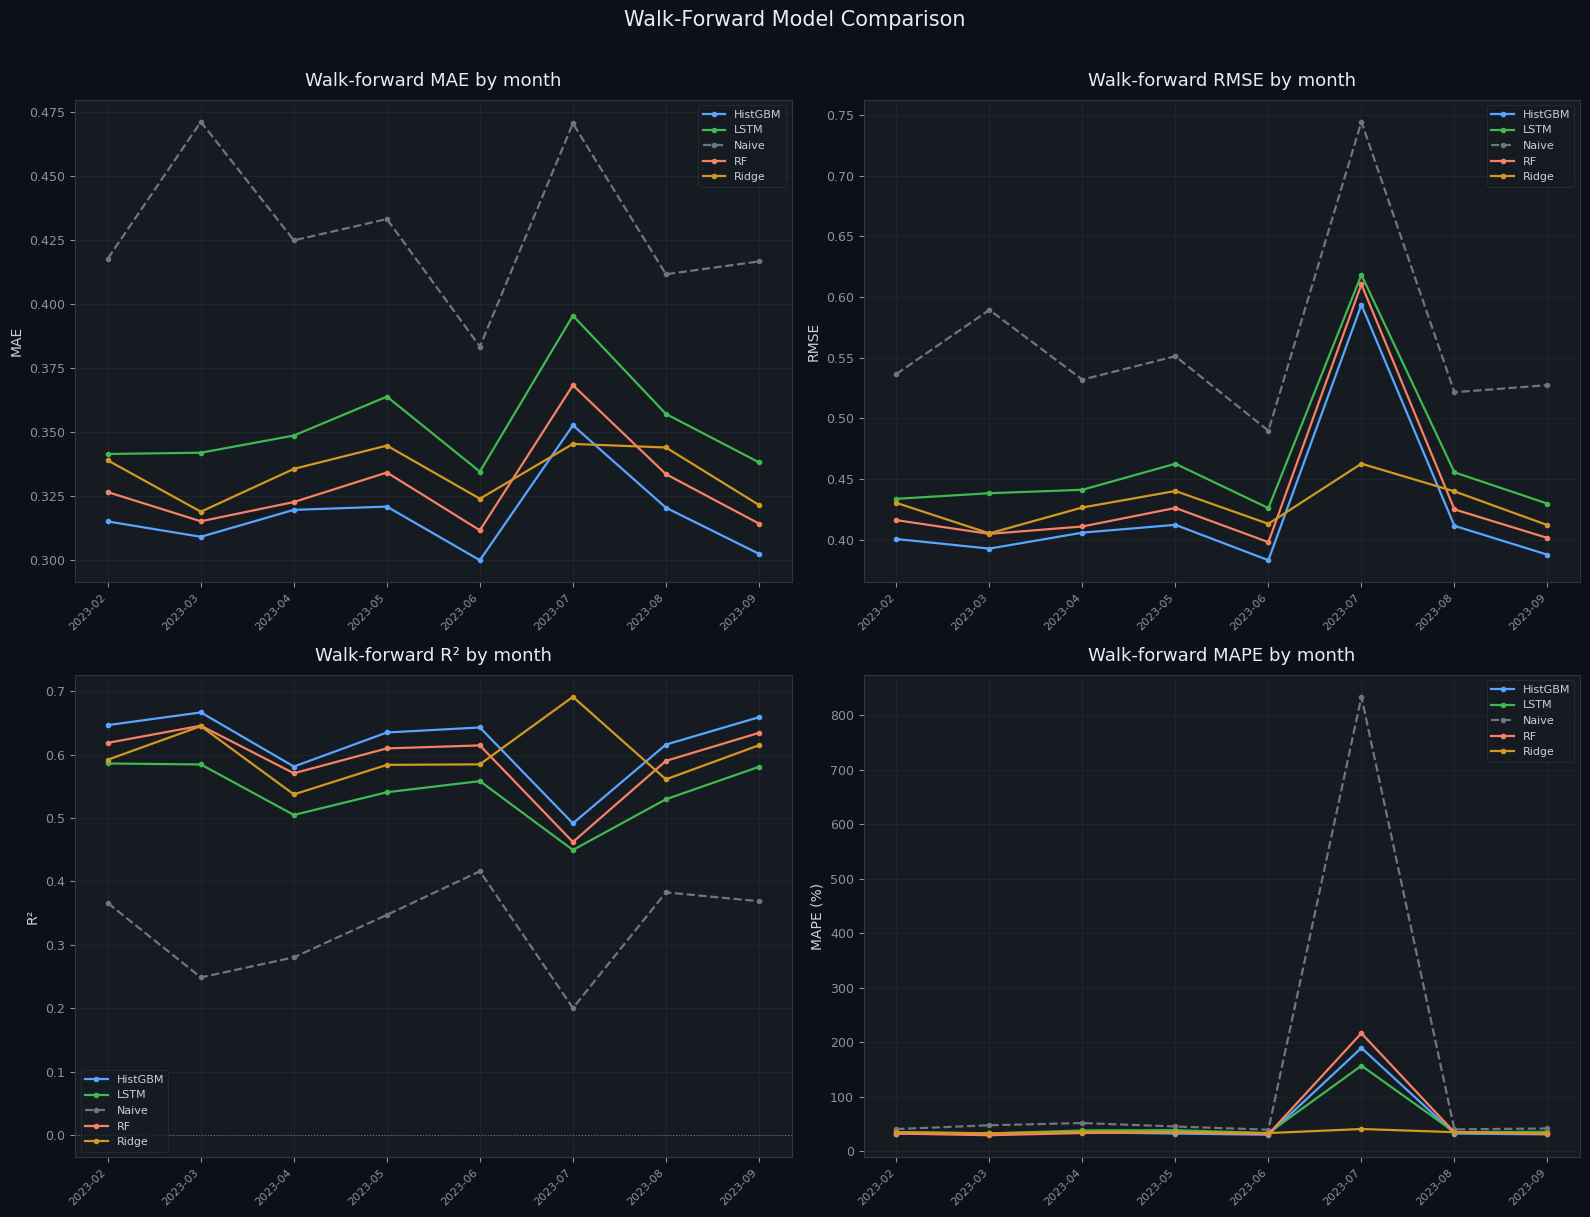

In [11]:
# Walk-forward Model Comparison
results_df = run_walk_forward(df_model, all_features, MODEL_NAMES)
summary    = summarize_results(results_df)
best_model = get_best_model(summary)

print(summary.round(4))
print(f"\nBest model selected: {best_model}")
plot_model_comparison(results_df)

In [12]:
# Warning - importance & pruning are only for HistGBM, RF, or Ridge
if best_model in ["LSTM", "Naive"]:
    raise ValueError(
        f"Best model is {best_model}. "
        "Importance and pruning are only implemented for HistGBM, RF, or Ridge."
    )
print(f"Proceeding with best model: {best_model}")

Proceeding with best model: HistGBM


QUANTILE MODELS  (median / Q05 / Q95)
  Fitting: median ...
  Fitting: q05 ...
  Fitting: q95 ...

Interval diagnostics (test set):
Coverage_90pct_interval      0.875059
Mean_interval_width_log      1.228932
Median_interval_width_log    1.250245
Quantile_Q05                 0.039166
Quantile_Q95                 0.045873
Median_MAE                   0.309709
Median_R2                    0.651956
dtype: float64


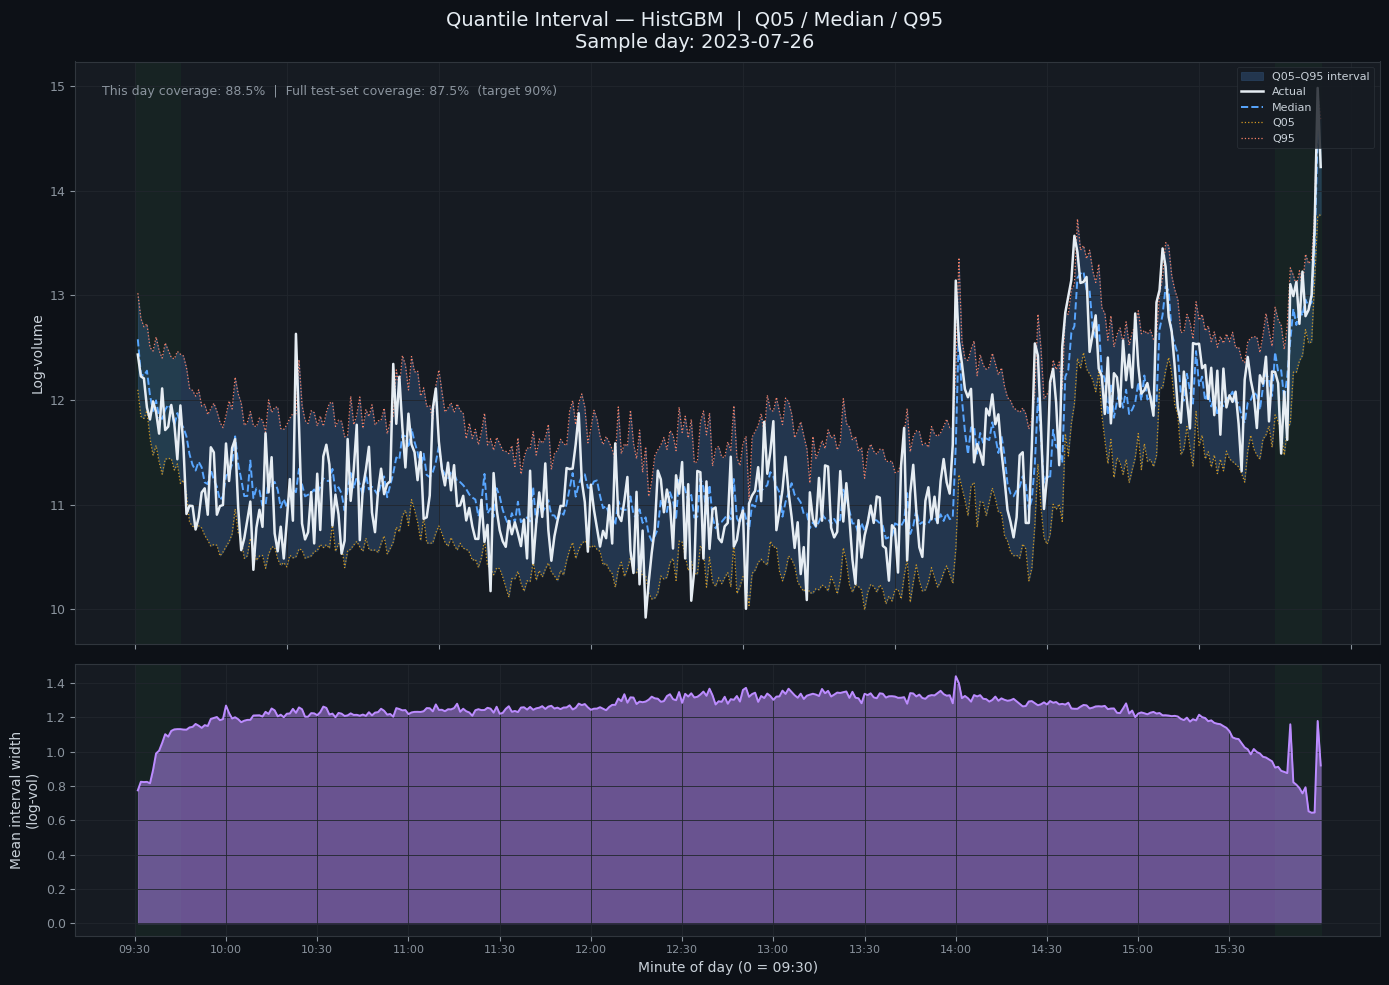

In [13]:
# Train/Test Split & Quantile Models
split     = int(len(df_model) * 0.8)
X_tr_diag = df_model.iloc[:split][all_features]
y_tr_diag = df_model.iloc[:split]["log_vol"].values
X_te_diag = df_model.iloc[split:][all_features]
y_te_diag = df_model.iloc[split:]["log_vol"].values

if best_model == "HistGBM":
    print("=" * 60)
    print("QUANTILE MODELS  (median / Q05 / Q95)")
    print("=" * 60)
    q_models          = fit_quantile_models(X_tr_diag.values, y_tr_diag)
    q_results, q_diag = evaluate_quantile_models(q_models, X_te_diag.values, y_te_diag)
    print("\nInterval diagnostics (test set):")
    print(q_diag.round(6))
    plot_quantile_intervals(
        q_models=q_models,
        df_te=df_model.iloc[split:].copy(),
        features=all_features,
        best_model_name=best_model,
    )
else:
    print(f"[INFO] Quantile models skipped — best model is '{best_model}', not HistGBM.")
    q_models = None

Computing walk-forward importance over 3 folds...
  2023-07 | train: 33,146  test: 7,718
  2023-08 | train: 31,894  test: 8,970
  2023-09 | train: 33,454  test: 7,800
             Feature  Importance       Std
0          lag_1_log    0.140829  0.020830
1          ma_10_log    0.092760  0.014342
2               rvol    0.032943  0.007149
3      minute_of_day    0.015695  0.002952
4            min_cos    0.008626  0.001828
5              ret_5    0.007910  0.001334
6            min_sin    0.006984  0.000693
7             ret_10    0.006857  0.000035
8           vwap_dev    0.006841  0.001709
9   intraday_cum_vol    0.003395  0.001754
10             ret_1    0.001408  0.000354
11        lower_wick    0.001329  0.000446
12              body    0.001087  0.000432
13         bar_range    0.001043  0.000532
14   realized_vol_15    0.000862  0.000223
15        upper_wick    0.000822  0.000597
16       day_of_week    0.000730  0.000107
17           gap_pct    0.000674  0.000135
18         lag_5

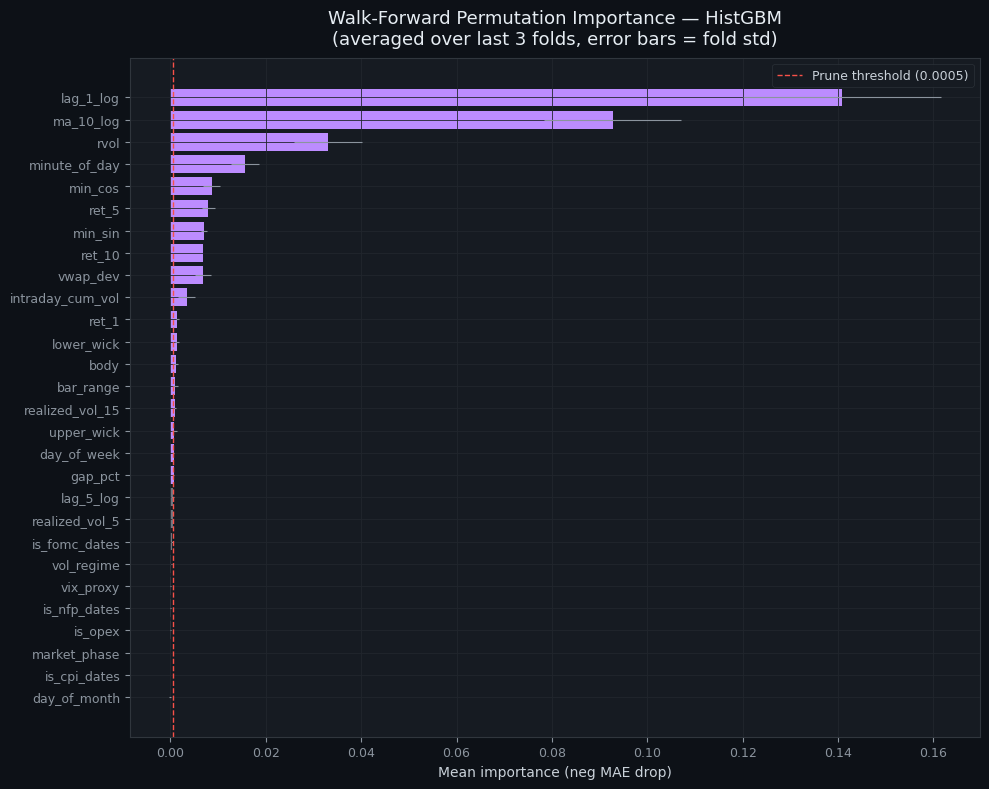

In [14]:
# Walk-Forward Permutation Importance
imp_df = compute_importance_walk_forward(
    best_model_name=best_model,
    df_model=df_model,
    features=all_features,
    n_folds=IMPORTANCE_FOLDS,
)
print(imp_df.round(6))
plot_feature_importance(imp_df, best_model)

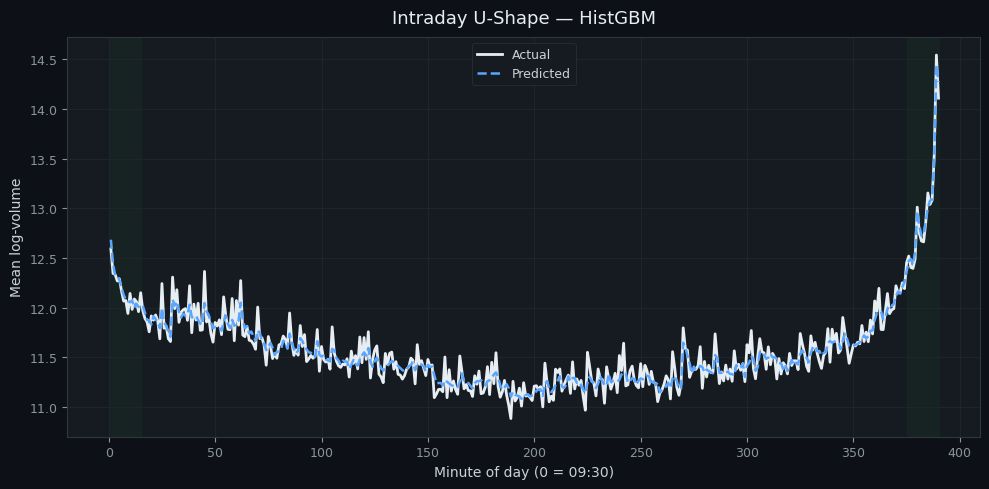

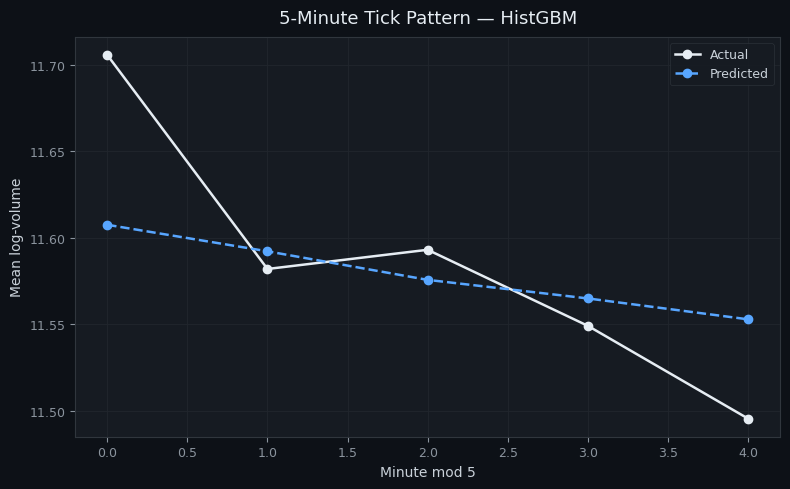

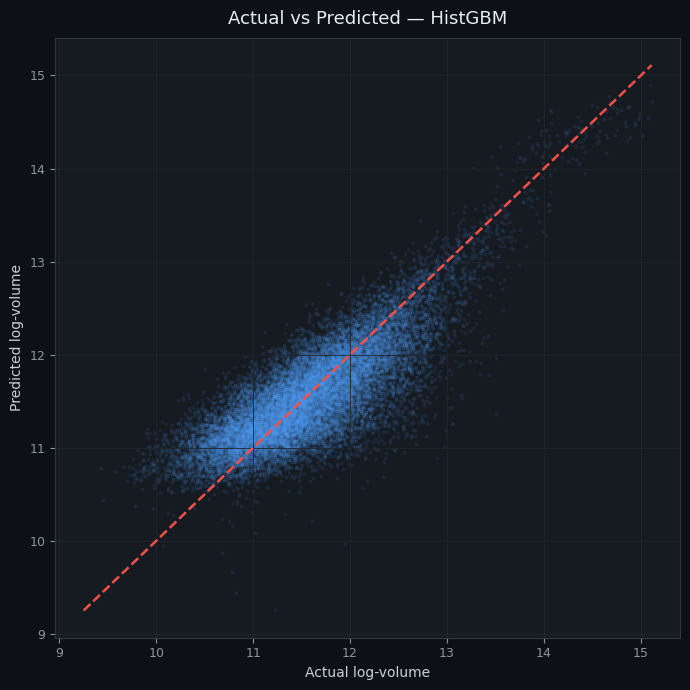

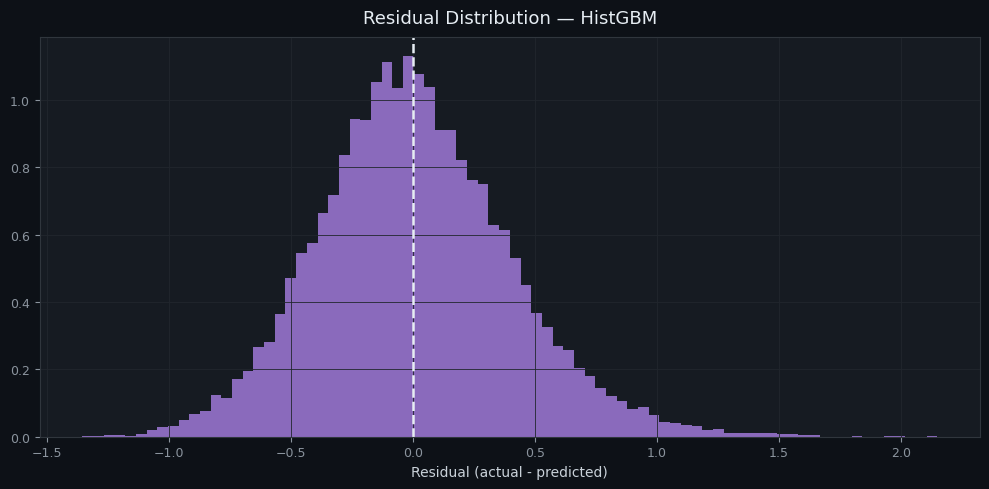

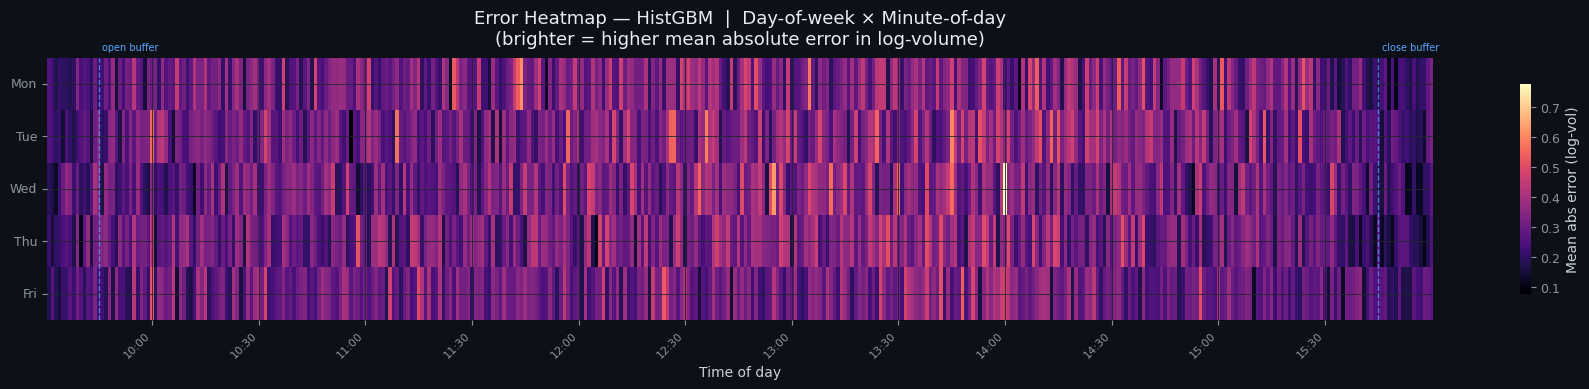

In [15]:
# Best Model Diagnostics & Error Heatmap
best_model_fit = fit_best_model(best_model, X_tr_diag, y_tr_diag)
plot_best_model_diagnostics(df_model, split, best_model, best_model_fit, all_features)
plot_error_heatmap(df_model, split, best_model, best_model_fit, all_features)

In [16]:
# Feature pruning
pruned_features   = prune_features(imp_df)
pruned_results_df = run_walk_forward(df_model, pruned_features, [best_model])
pruned_summary    = summarize_results(pruned_results_df)

print(f"Original features : {len(all_features)}")
print(f"Pruned features   : {len(pruned_features)}")
print("\nKept features:")
for f in pruned_features:
    print(f"  - {f}")

before_row = summary.loc[best_model]
after_row  = pruned_summary.loc[best_model]
comparison = pd.DataFrame({
    "Metric":         ["MAE","RMSE","R2","MAPE"],
    "Before_Pruning": [before_row["MAE_mean"], before_row["RMSE_mean"],
                       before_row["R2_mean"],  before_row["MAPE_mean"]],
    "After_Pruning":  [after_row["MAE_mean"],  after_row["RMSE_mean"],
                       after_row["R2_mean"],   after_row["MAPE_mean"]],
})
comparison["Delta"] = comparison["After_Pruning"] - comparison["Before_Pruning"]
print("\nPruning impact:")
print(comparison.round(4))

Starting walk-forward  |  TRAIN_WINDOW=4

  2023-02 | train: 30,359  test: 7,410
  2023-03 | train: 31,529  test: 8,970
  2023-04 | train: 32,370  test: 7,410
  2023-05 | train: 31,590  test: 8,580
  2023-06 | train: 32,370  test: 8,186
  2023-07 | train: 33,146  test: 7,718
  2023-08 | train: 31,894  test: 8,970
  2023-09 | train: 33,454  test: 7,800
Original features : 28
Pruned features   : 18

Kept features:
  - lag_1_log
  - ma_10_log
  - rvol
  - minute_of_day
  - min_cos
  - ret_5
  - min_sin
  - ret_10
  - vwap_dev
  - intraday_cum_vol
  - ret_1
  - lower_wick
  - body
  - bar_range
  - realized_vol_15
  - upper_wick
  - day_of_week
  - gap_pct

Pruning impact:
  Metric  Before_Pruning  After_Pruning   Delta
0    MAE          0.3174         0.3165 -0.0009
1   RMSE          0.4235         0.4226 -0.0009
2     R2          0.6172         0.6188  0.0016
3   MAPE         52.1127        49.8576 -2.2551
